# **StresID: a multimodal dataset for Stress Detection**

### **Basic EDA on existance dataset**
- self_assessments.csv
- demographics.csv

In [2]:
# !pip install numpy pandas matplotlib seaborn plotly openpyxl -q

In [3]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

In [4]:
# Read and Load dataset
self_assessment = pd.read_csv('data/self_assessments.csv', sep=';', header=0)
demographics = pd.read_csv('data/demographics.csv', sep=';')
print("Self Assessment Dataset:")
print(self_assessment.head())
print(self_assessment.tail())
print("\nDemographics Dataset:")
print(demographics.head())

Self Assessment Dataset:
               Tasks hh2e wfsl 37ir hvpa ql3b r0a3 qx2o wssm ctzy  ... y8c3  \
0    Breathing_relax    6    6    9    9   10   10    9    8    9  ...    9   
1   Breathing_stress    5    4    2    1    1    0    2    0    0  ...    1   
2  Breathing_valence  NaN    8    5    7    5    8    8    6    7  ...    5   
3  Breathing_arousal  NaN    3    3    8    2    1    2    1    7  ...    7   
4       Video1_relax    8    6    3    7   10   10    9    5    4  ...    8   

  g7r2 f6q3 e5p4 d4n6 c3m7 b2l8 a1k9 t6v9 b9w0  
0    8    9   10    5    4    8    7    5    8  
1    0    1    3    2    6    1    5    5    2  
2    7    7    8    5    8    7    6    6    7  
3    5    1    3    4    7    8    8    3    8  
4    8    9    8    2    2    2    7    7    5  

[5 rows x 66 columns]
             Tasks       hh2e       wfsl      37ir     hvpa      ql3b  \
40     Relax_relax          6        NaN         7        6        10   
41    Relax_stress          6        

In [5]:
# # Load and transpose self_assessment dataset
# df = pd.read_csv('data/self_assessments.csv', sep=';', index_col='Tasks').T
# df.index.name = 'Instance'
# df.to_csv('self_assessments_transposed.csv')

# print(df.head())
# print(f"\nShape: {df.shape}")

### **Preprocessing**

In [6]:
# Remove the last row from self_assessment dataset
self_assessment = self_assessment[:-1]
# print("\nUpdated Self Assessment Dataset:")
# print(self_assessment.tail())

# Store the column names of self_assessment dataset in 'subjects'
subjects = self_assessment.columns[1:]

# Converts the data in "subjects" into fload
self_assessment[subjects] = self_assessment[subjects].astype(float)
print("\nData types of self_assessment dataset:")
self_assessment.tail()


Data types of self_assessment dataset:


,Tasks,hh2e,wfsl,37ir,hvpa,ql3b,r0a3,qx2o,wssm,ctzy,...,y8c3,g7r2,f6q3,e5p4,d4n6,c3m7,b2l8,a1k9,t6v9,b9w0
39,Counting3_arousal,NaN,6.0,8.0,8.0,10.0,6.0,6.0,6.0,9.0,...,5.0,4.0,3.0,5.0,6.0,5.0,6.0,7.0,8.0,8.0
40,Relax_relax,6.0,NaN,7.0,6.0,10.0,10.0,4.0,7.0,9.0,...,9.0,8.0,9.0,8.0,5.0,7.0,6.0,8.0,3.0,2.0
41,Relax_stress,6.0,NaN,1.0,2.0,0.0,1.0,5.0,0.0,1.0,...,0.0,0.0,1.0,2.0,3.0,5.0,5.0,3.0,3.0,5.0
42,Relax_valence,NaN,NaN,7.0,6.0,8.0,6.0,5.0,7.0,5.0,...,6.0,5.0,8.0,7.0,5.0,6.0,7.0,8.0,5.0,5.0
43,Relax_arousal,NaN,NaN,6.0,5.0,8.0,2.0,3.0,0.0,1.0,...,4.0,2.0,1.0,3.0,3.0,7.0,6.0,5.0,0.0,4.0


In [7]:
# Organize and filter data based on combinations of subjects and tasks

# Define tasks
tasks = ["Breathing", "Video1", "Video2", "Counting1", "Counting2", 
         "Stroop", "Math", "Speaking", "Reading", "Counting3", "Relax"]

# Creating the Unique Keys to pair up every single subject with every single task
unique_keys = [f"{subject}_{task}" for subject in subjects for task in tasks]
# print("\nUnique Keys for Subject-Task Combinations:")
# print(unique_keys)

# Creates a dictionary with the keys combinations, and all the values are initially set to None
labels_Dict = dict.fromkeys(unique_keys)
print("\nInitial Labels Dictionary with Unique Keys:")
print(labels_Dict)

# Loop through each subject and task to populate the labels_Dict with the corresponding values from the self_assessment dataset
for label in unique_keys:
    subject, task = label.split('_')[0], label.split('_')[1]
    labels_Dict[label] = list(self_assessment[self_assessment['Tasks'].str.contains(task)][subject])

labels = pd.DataFrame(labels_Dict)
labels.index = ['relax', 'stress', 'valence', 'arousal']
print("\nLabels DataFrame with Subject-Task Combinations:")
labels.head()


Initial Labels Dictionary with Unique Keys:
{'hh2e_Breathing': None, 'hh2e_Video1': None, 'hh2e_Video2': None, 'hh2e_Counting1': None, 'hh2e_Counting2': None, 'hh2e_Stroop': None, 'hh2e_Math': None, 'hh2e_Speaking': None, 'hh2e_Reading': None, 'hh2e_Counting3': None, 'hh2e_Relax': None, 'wfsl_Breathing': None, 'wfsl_Video1': None, 'wfsl_Video2': None, 'wfsl_Counting1': None, 'wfsl_Counting2': None, 'wfsl_Stroop': None, 'wfsl_Math': None, 'wfsl_Speaking': None, 'wfsl_Reading': None, 'wfsl_Counting3': None, 'wfsl_Relax': None, '37ir_Breathing': None, '37ir_Video1': None, '37ir_Video2': None, '37ir_Counting1': None, '37ir_Counting2': None, '37ir_Stroop': None, '37ir_Math': None, '37ir_Speaking': None, '37ir_Reading': None, '37ir_Counting3': None, '37ir_Relax': None, 'hvpa_Breathing': None, 'hvpa_Video1': None, 'hvpa_Video2': None, 'hvpa_Counting1': None, 'hvpa_Counting2': None, 'hvpa_Stroop': None, 'hvpa_Math': None, 'hvpa_Speaking': None, 'hvpa_Reading': None, 'hvpa_Counting3': None, 'h


Labels DataFrame with Subject-Task Combinations:


,hh2e_Breathing,hh2e_Video1,hh2e_Video2,hh2e_Counting1,hh2e_Counting2,hh2e_Stroop,hh2e_Math,hh2e_Speaking,hh2e_Reading,hh2e_Counting3,...,b9w0_Video1,b9w0_Video2,b9w0_Counting1,b9w0_Counting2,b9w0_Stroop,b9w0_Math,b9w0_Speaking,b9w0_Reading,b9w0_Counting3,b9w0_Relax
relax,6.0,8.0,7.0,6.0,3.0,6.0,5.0,6.0,8.0,5.0,...,5.0,4.0,3.0,1.0,3.0,3.0,2.0,2.0,1.0,2.0
stress,5.0,2.0,3.0,5.0,7.0,6.0,6.0,6.0,4.0,7.0,...,2.0,3.0,4.0,6.0,6.0,6.0,7.0,6.0,7.0,5.0
valence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,5.0,5.0,3.0,4.0,5.0,4.0,5.0,5.0,5.0
arousal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.0,7.0,9.0,9.0,9.0,9.0,9.0,5.0,8.0,4.0


In [8]:
# Transpose the labels DataFrame to have unique keys as rows and the corresponding values as columns
self_assessment_t = labels.transpose()
self_assessment_t.columns = ['Relax', 'Stress', 'Valence', 'Arousal']
print("\nTransposed Labels DataFrame:")
print(self_assessment_t[:20])
print(f"\nShape of Labels DataFrame: {self_assessment_t.shape}")

# # Save the labels DataFrame to a CSV file
# labels.to_csv('/data/labels.csv', index=True)
# print("\nLabels DataFrame saved to 'labels.csv' successfully.")


Transposed Labels DataFrame:
                Relax  Stress  Valence  Arousal
hh2e_Breathing    6.0     5.0      NaN      NaN
hh2e_Video1       8.0     2.0      NaN      NaN
hh2e_Video2       7.0     3.0      NaN      NaN
hh2e_Counting1    6.0     5.0      NaN      NaN
hh2e_Counting2    3.0     7.0      NaN      NaN
hh2e_Stroop       6.0     6.0      NaN      NaN
hh2e_Math         5.0     6.0      NaN      NaN
hh2e_Speaking     6.0     6.0      NaN      NaN
hh2e_Reading      8.0     4.0      NaN      NaN
hh2e_Counting3    5.0     7.0      NaN      NaN
hh2e_Relax        6.0     6.0      NaN      NaN
wfsl_Breathing    6.0     4.0      8.0      3.0
wfsl_Video1       6.0     3.0      7.0      2.0
wfsl_Video2       4.0     7.0      4.0      2.0
wfsl_Counting1    1.0     9.0      2.0      8.0
wfsl_Counting2    0.0    10.0      1.0      9.0
wfsl_Stroop       4.0     7.0      4.0      7.0
wfsl_Math         2.0     6.0      3.0      6.0
wfsl_Speaking     5.0     4.0      5.0      5.0
wfsl_Readi

### **EDA on self_assessment dataset**

In [9]:
# Check for missing values and NaN-values in the labels DataFrame
print("\nMissing Values in Labels DataFrame:")
print(self_assessment_t.isnull().sum())
print(f"\nTotal Missing Values: {self_assessment_t.isnull().sum().sum()}")


Missing Values in Labels DataFrame:
Relax       1
Stress      1
Valence    12
Arousal    12
dtype: int64

Total Missing Values: 26


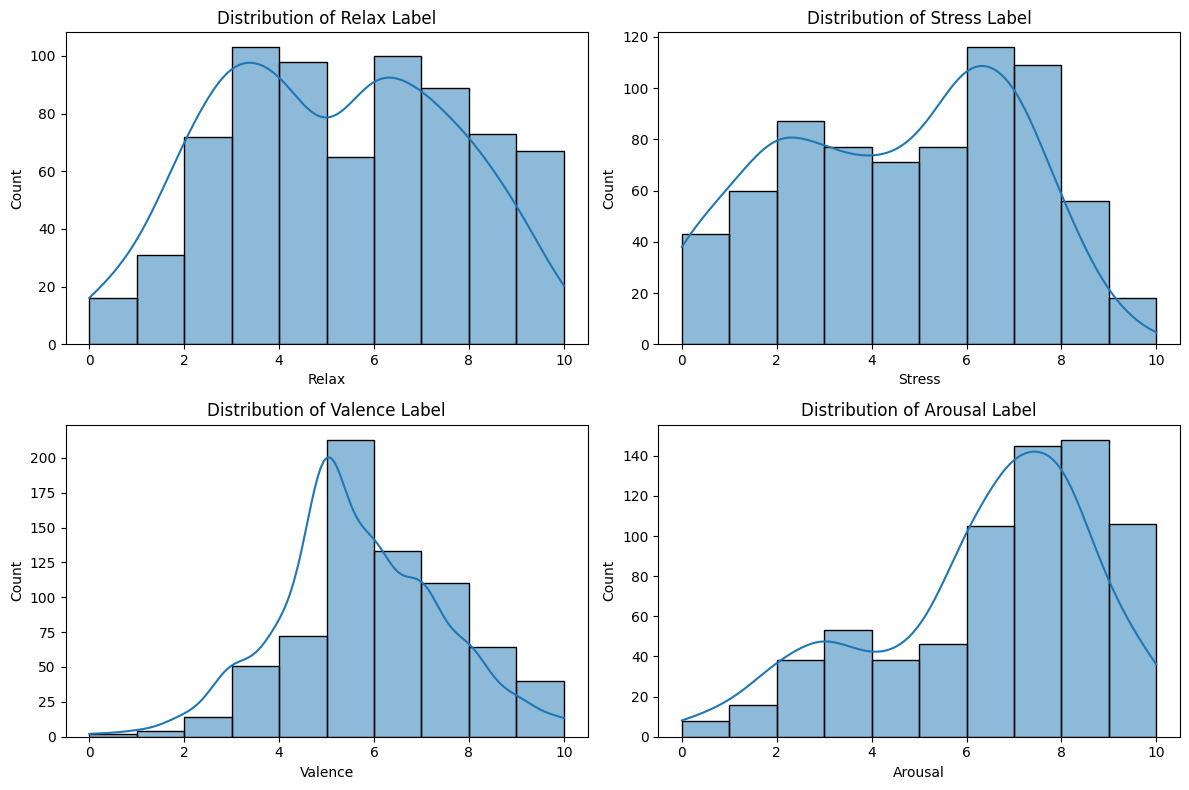

In [10]:
# Visualize the distribution of the 'Relax', 'Stress', 'Valence', and 'Arousal' labels using histograms
plt.figure(figsize=(12, 8))
for i, column in enumerate(self_assessment_t.columns):
    plt.subplot(2, 2, i + 1)
    sns.histplot(self_assessment_t[column], bins=10, kde=True)
    plt.title(f'Distribution of {column} Label')
plt.tight_layout()
plt.show()

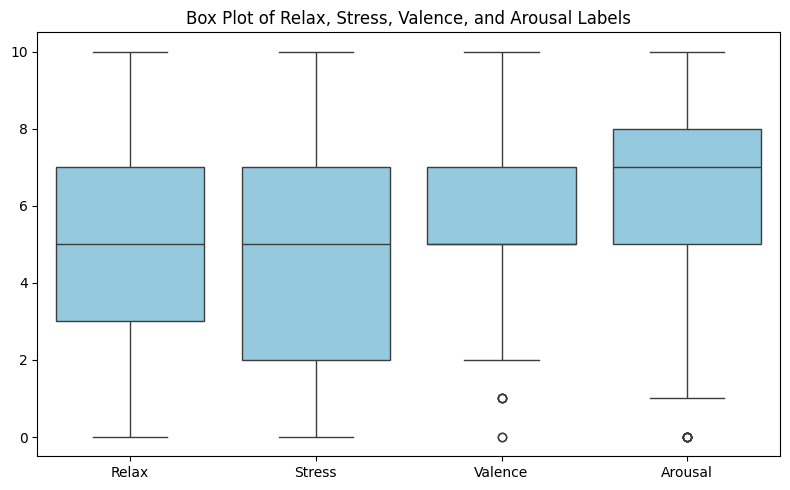

In [11]:
# Visualize the distribution of the 'Relax', 'Stress', 'Valence', and 'Arousal' labels using vertical box plots
plt.figure(figsize=(8, 5))
sns.boxplot(data=self_assessment_t, orient='v', color='skyblue')
plt.title('Box Plot of Relax, Stress, Valence, and Arousal Labels')
plt.tight_layout()
plt.show()

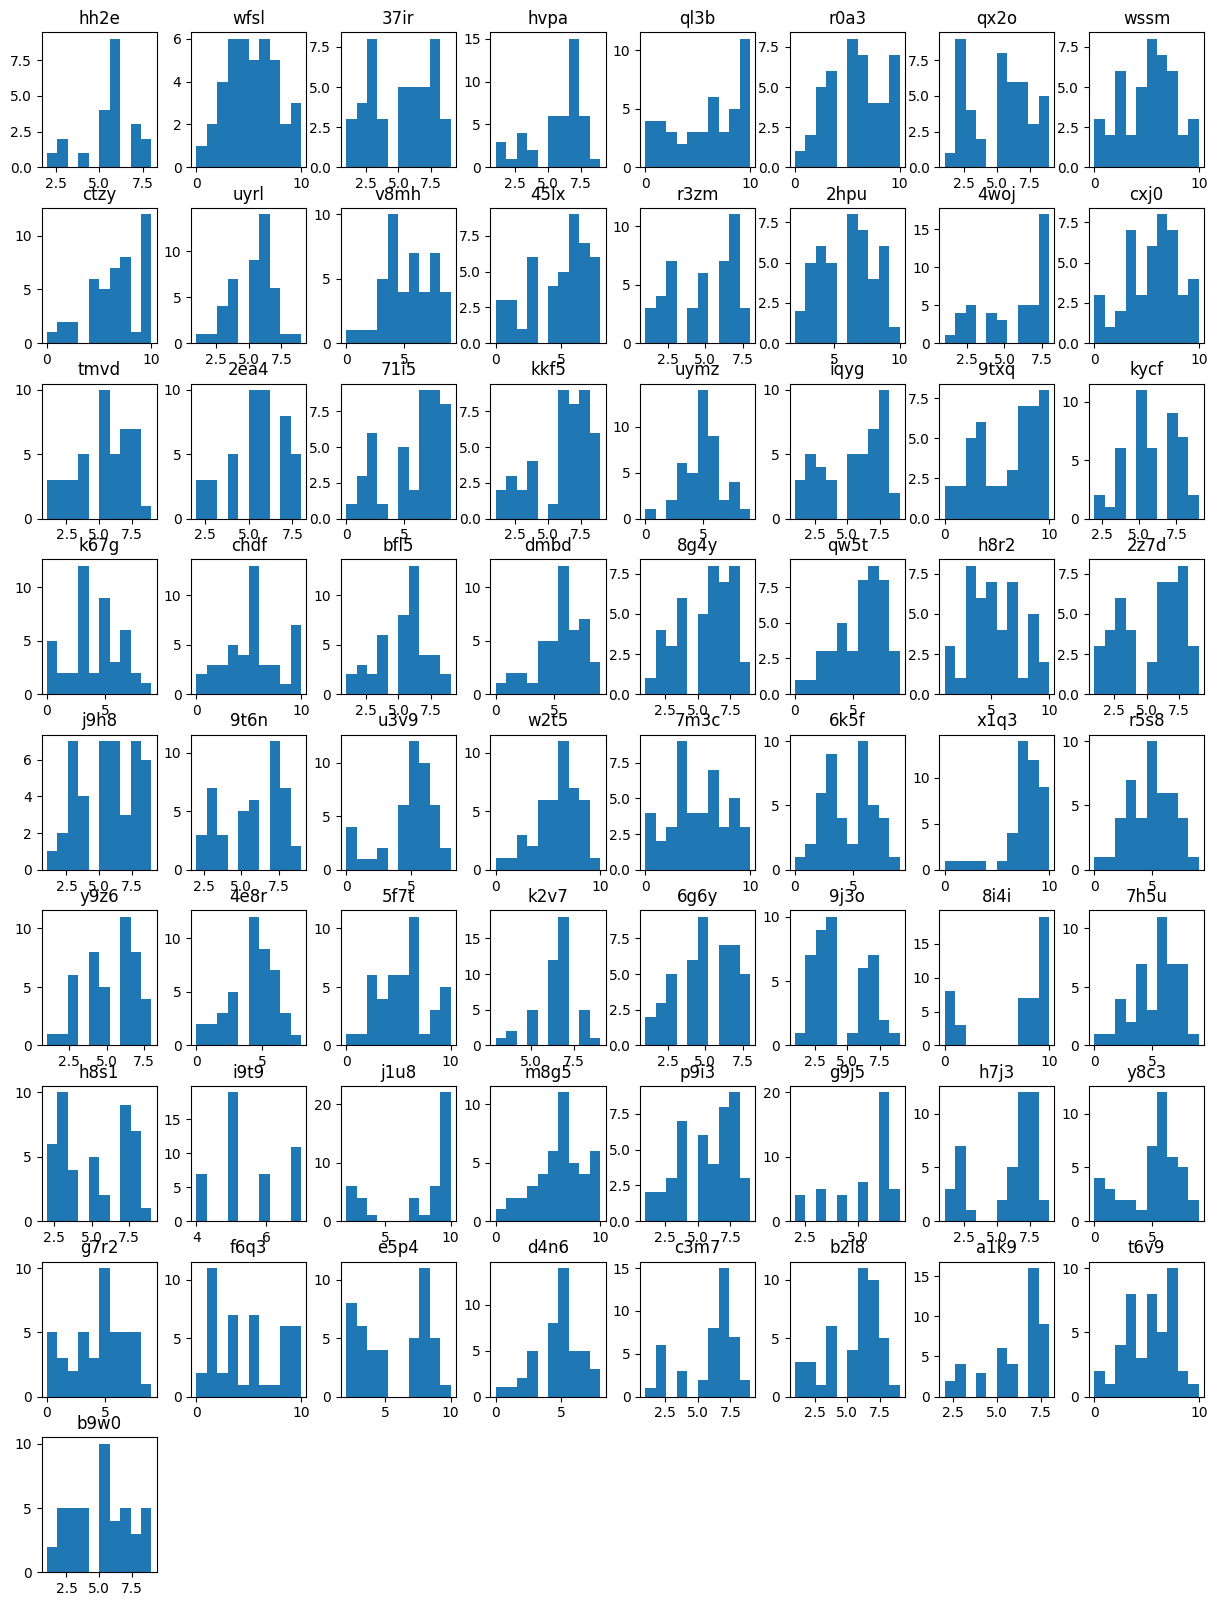

In [12]:
# distribution of grouped by subjects across all tasks and assessment
hist_ = self_assessment.hist(grid=False, figsize = (15,20))

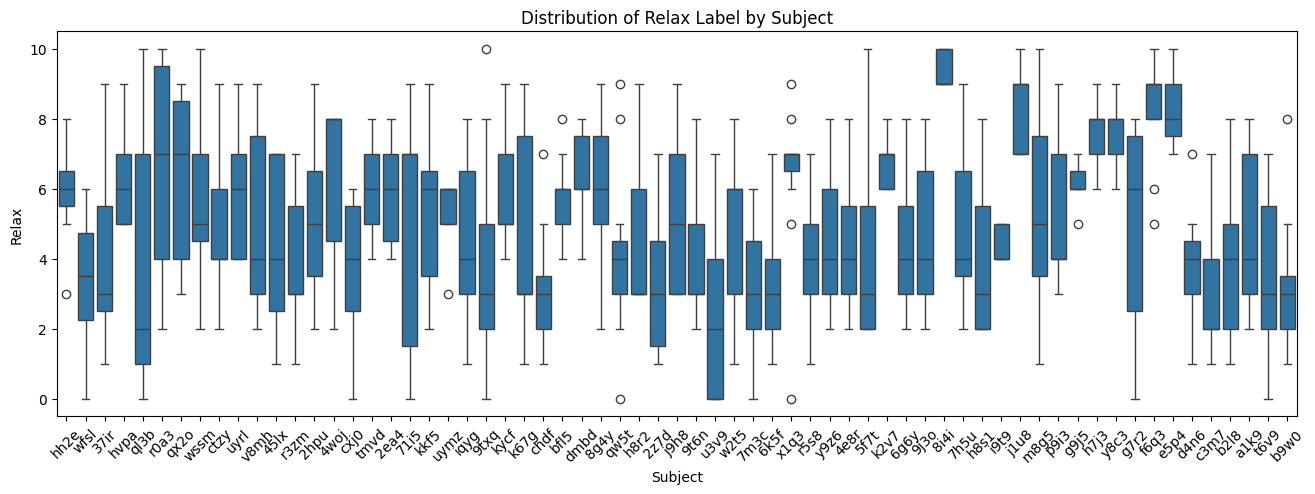

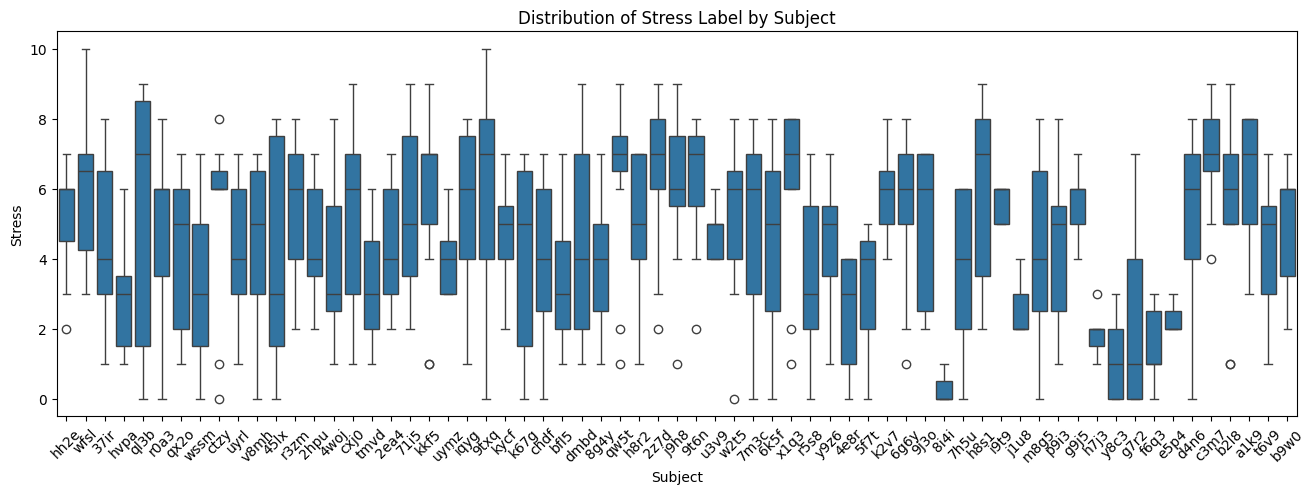

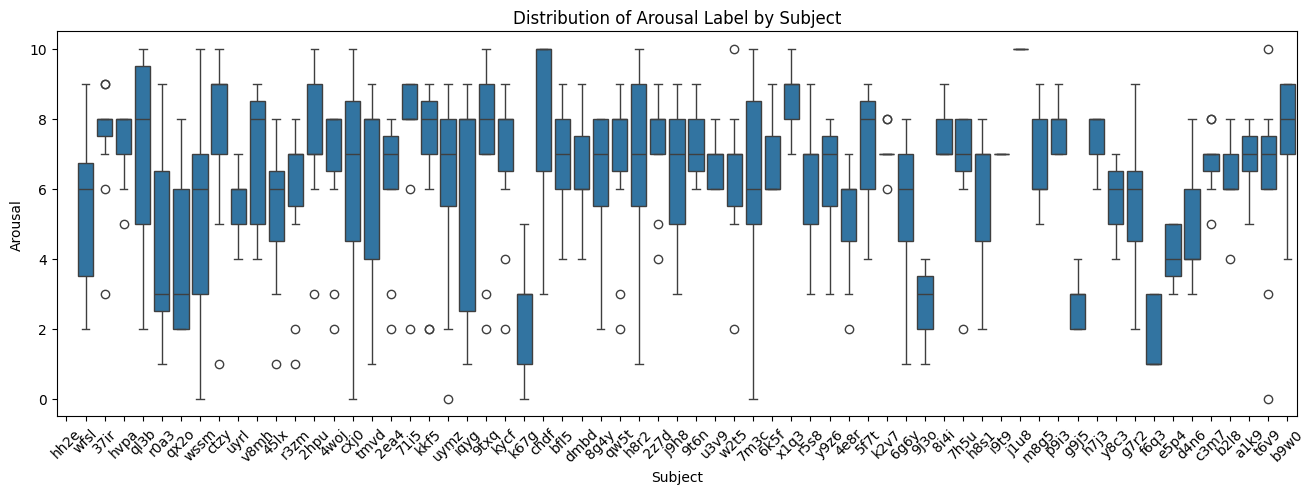

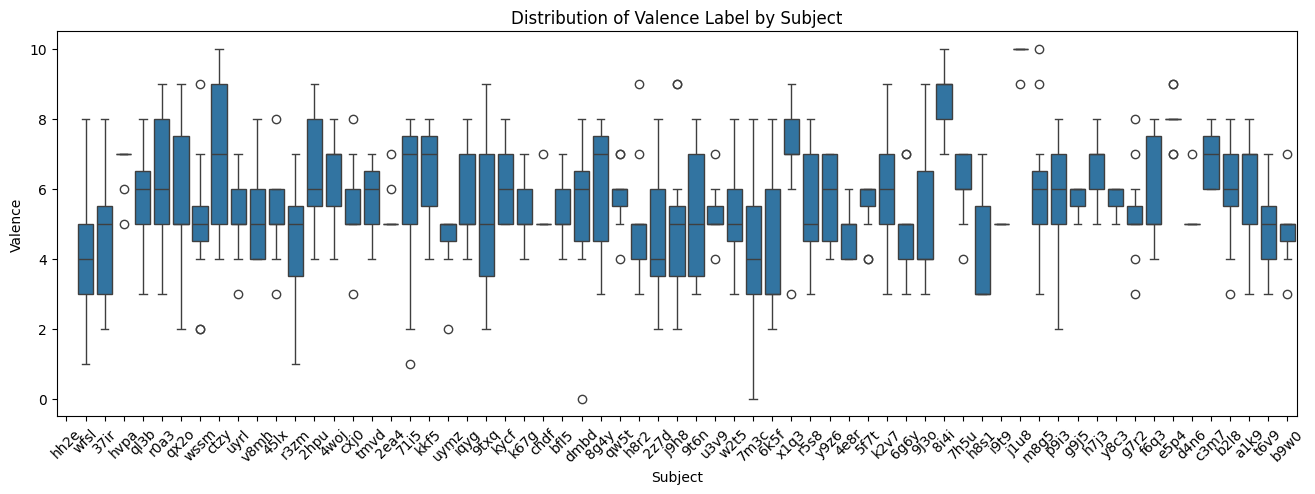

In [13]:
# Visualize the distribution of grouped by subjects across all tasks and assessment
self_assessment_t['Subject'] = self_assessment_t.index.str.split('_').str[0]
plt.figure(figsize=(16, 5))
sns.boxplot(x='Subject', y='Relax', data=self_assessment_t)
plt.title('Distribution of Relax Label by Subject')
plt.xticks(rotation=45)
plt.show()

# Visualize the distribution of grouped by subjects across all tasks and assessment
plt.figure(figsize=(16, 5))
sns.boxplot(x='Subject', y='Stress', data=self_assessment_t)
plt.title('Distribution of Stress Label by Subject')
plt.xticks(rotation=45)
plt.show()

# Visualize the distribution of grouped by subjects across all tasks and assessment
plt.figure(figsize=(16, 5))
sns.boxplot(x='Subject', y='Arousal', data=self_assessment_t)
plt.title('Distribution of Arousal Label by Subject')
plt.xticks(rotation=45)
plt.show()

# Visualize the distribution of grouped by subjects across all tasks and assessment
plt.figure(figsize=(16, 5))
sns.boxplot(x='Subject', y='Valence', data=self_assessment_t)
plt.title('Distribution of Valence Label by Subject')
plt.xticks(rotation=45)
plt.show()

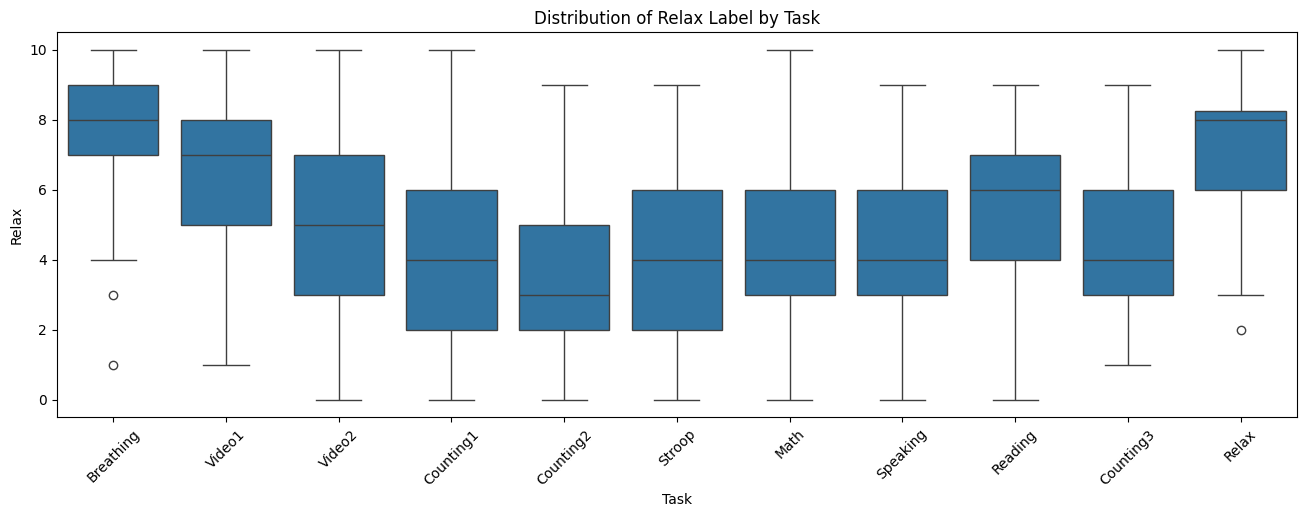

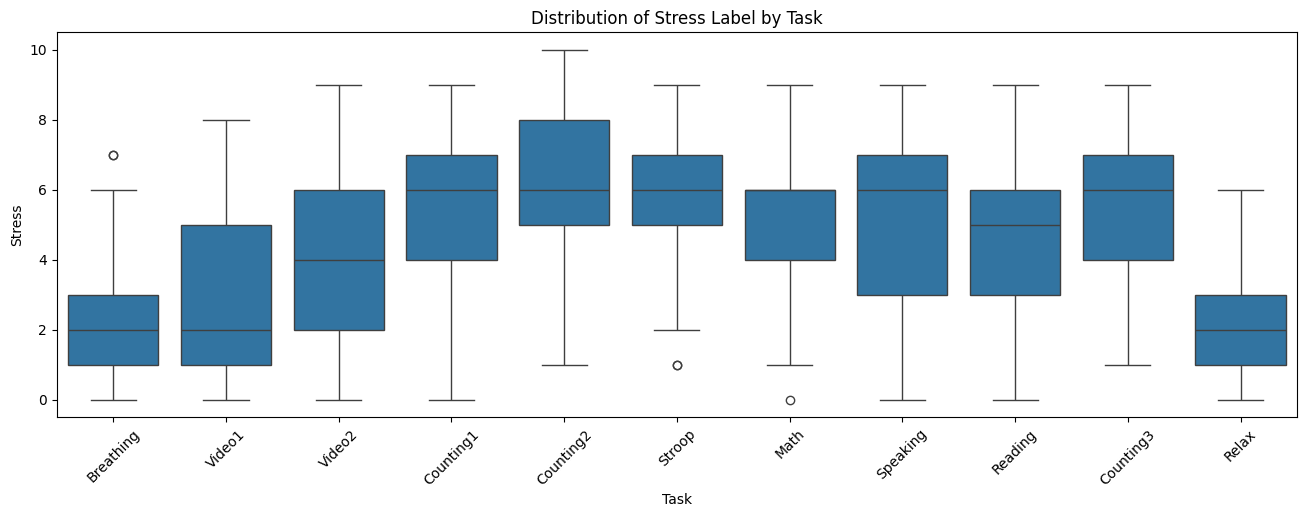

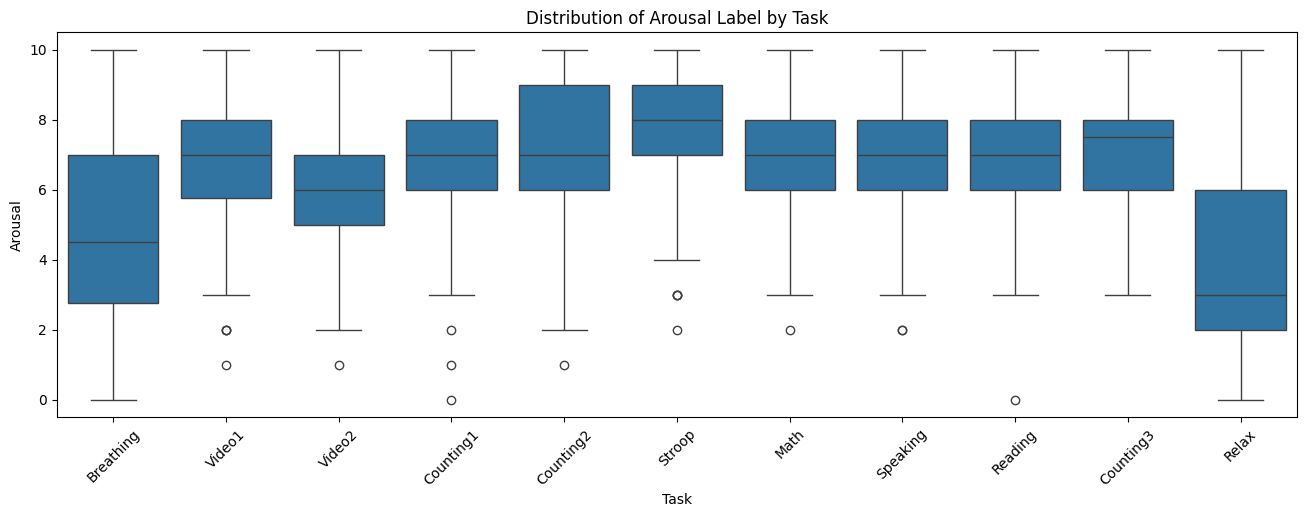

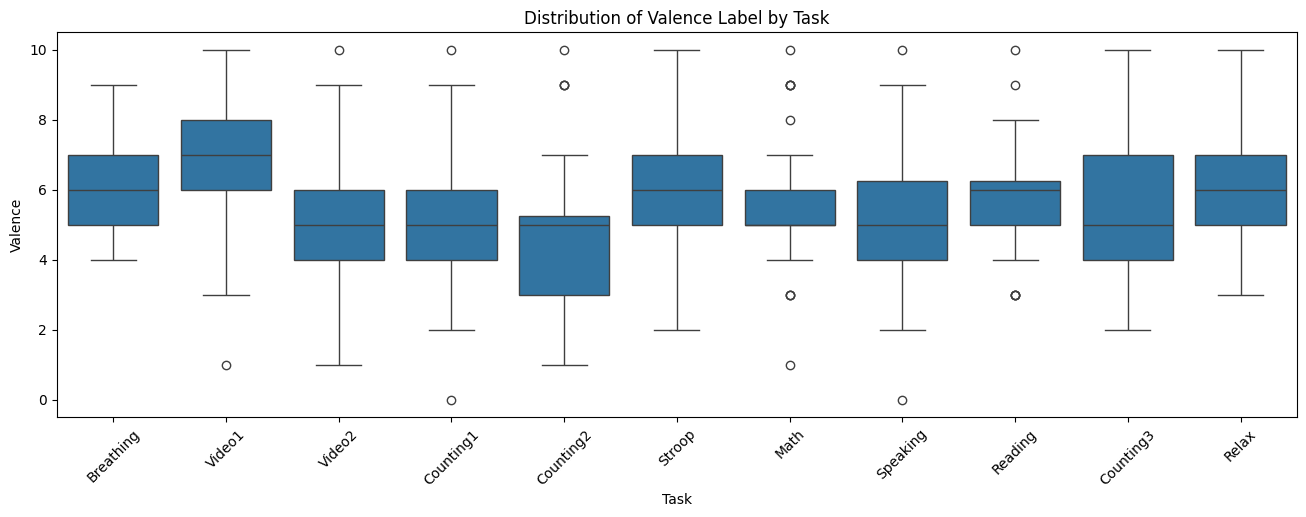

In [14]:
# Visualize the distribution of grouped by subjects across each tasks and assessment
self_assessment_t['Task'] = self_assessment_t.index.str.split('_').str[1]
plt.figure(figsize=(16, 5))
sns.boxplot(x='Task', y='Relax', data=self_assessment_t)
plt.title('Distribution of Relax Label by Task')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(16, 5))
sns.boxplot(x='Task', y='Stress', data=self_assessment_t)
plt.title('Distribution of Stress Label by Task')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(16, 5))
sns.boxplot(x='Task', y='Arousal', data=self_assessment_t)
plt.title('Distribution of Arousal Label by Task')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(16, 5))
sns.boxplot(x='Task', y='Valence', data=self_assessment_t)
plt.title('Distribution of Valence Label by Task')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_2656/1974626565.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=label_valence, fill=True, palette="hls", ax=axs[1, 0])


/tmp/ipykernel_2656/1974626565.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=label_arousal, fill=True, palette="hls", ax=axs[1, 1], legend=False)


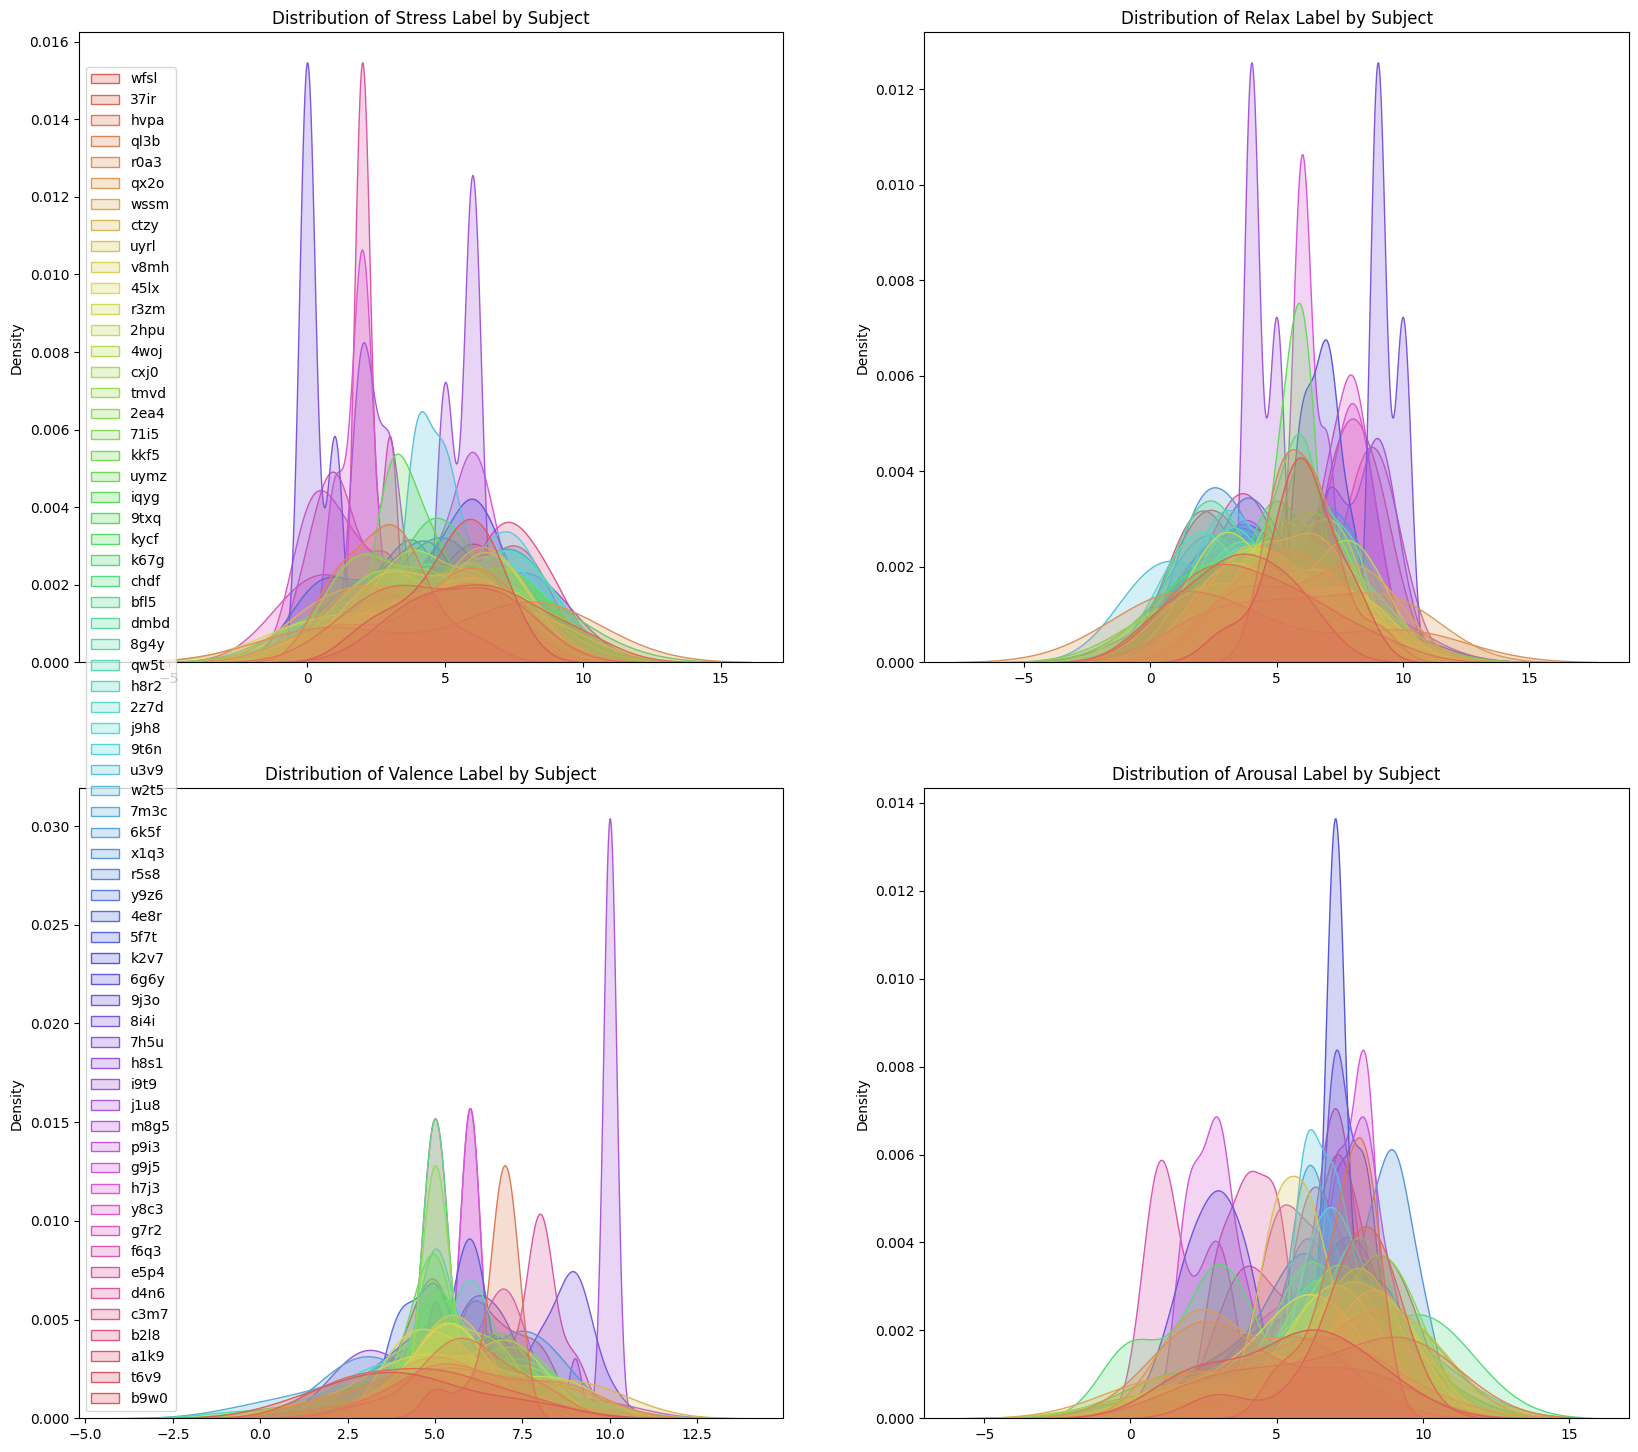

In [15]:
# kdeplot Grouped by assessment, accross all tasks and for each subject use labels dataset
label_stress = self_assessment[self_assessment["Tasks"].str.contains("stress")]
label_relax = self_assessment[self_assessment["Tasks"].str.contains("relax")]
label_valence = self_assessment[self_assessment["Tasks"].str.contains("valence")].drop(columns = "hh2e")
label_arousal = self_assessment[self_assessment["Tasks"].str.contains("arousal")].drop(columns = "hh2e")

fig, axs = plt.subplots(2,2, figsize=(20, 18))
sns.kdeplot(data=label_stress, fill=True, palette="hls", ax=axs[0, 0], legend=False)
axs[0, 0].set_title('Distribution of Stress Label by Subject')
sns.kdeplot(data=label_relax, fill=True, palette="hls", ax=axs[0, 1], legend=False)
axs[0, 1].set_title('Distribution of Relax Label by Subject')
sns.kdeplot(data=label_valence, fill=True, palette="hls", ax=axs[1, 0])
axs[1, 0].set_title('Distribution of Valence Label by Subject')
sns.kdeplot(data=label_arousal, fill=True, palette="hls", ax=axs[1, 1], legend=False)
axs[1, 1].set_title('Distribution of Arousal Label by Subject')
plt.show()

### **Intercorrelations**
#### Stress with respect to valence and arousal

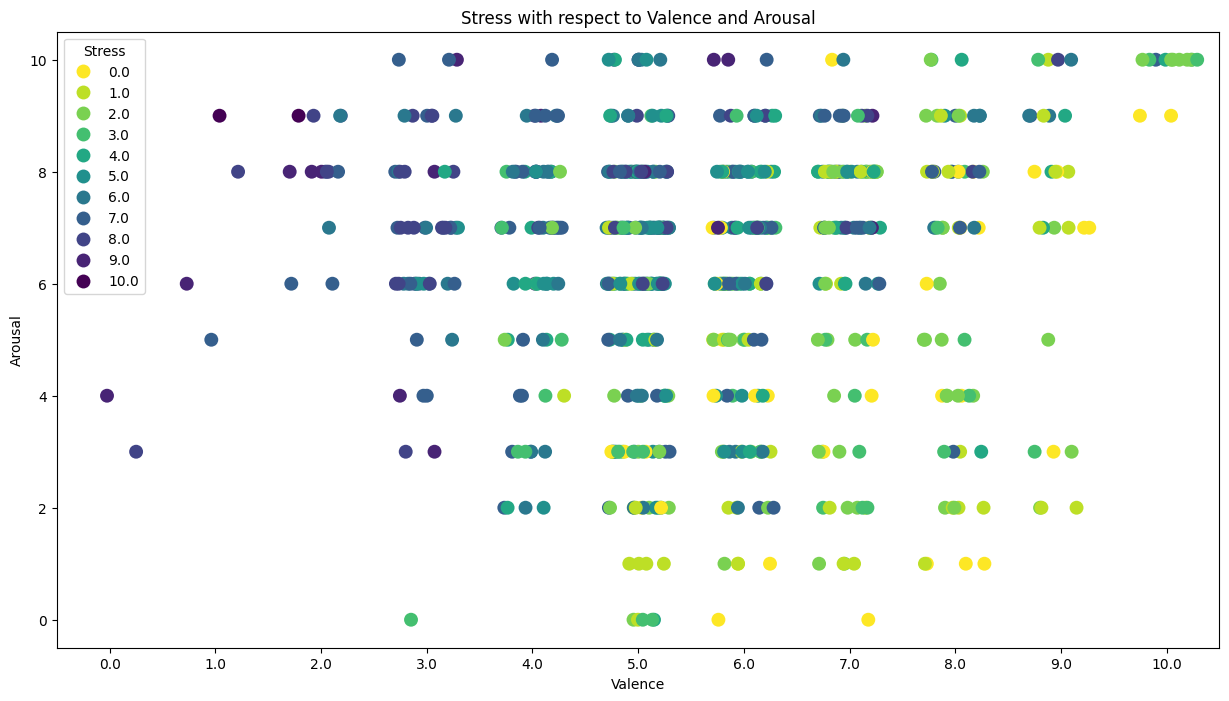

In [16]:
# Stress with respect to valence and arousal
plt.figure(figsize=(15, 8))
sns.stripplot(data=self_assessment_t, x='Valence', y='Arousal', hue='Stress',
              palette='viridis_r', size=10, jitter=0.3, legend='full')
plt.title('Stress with respect to Valence and Arousal')
plt.show()

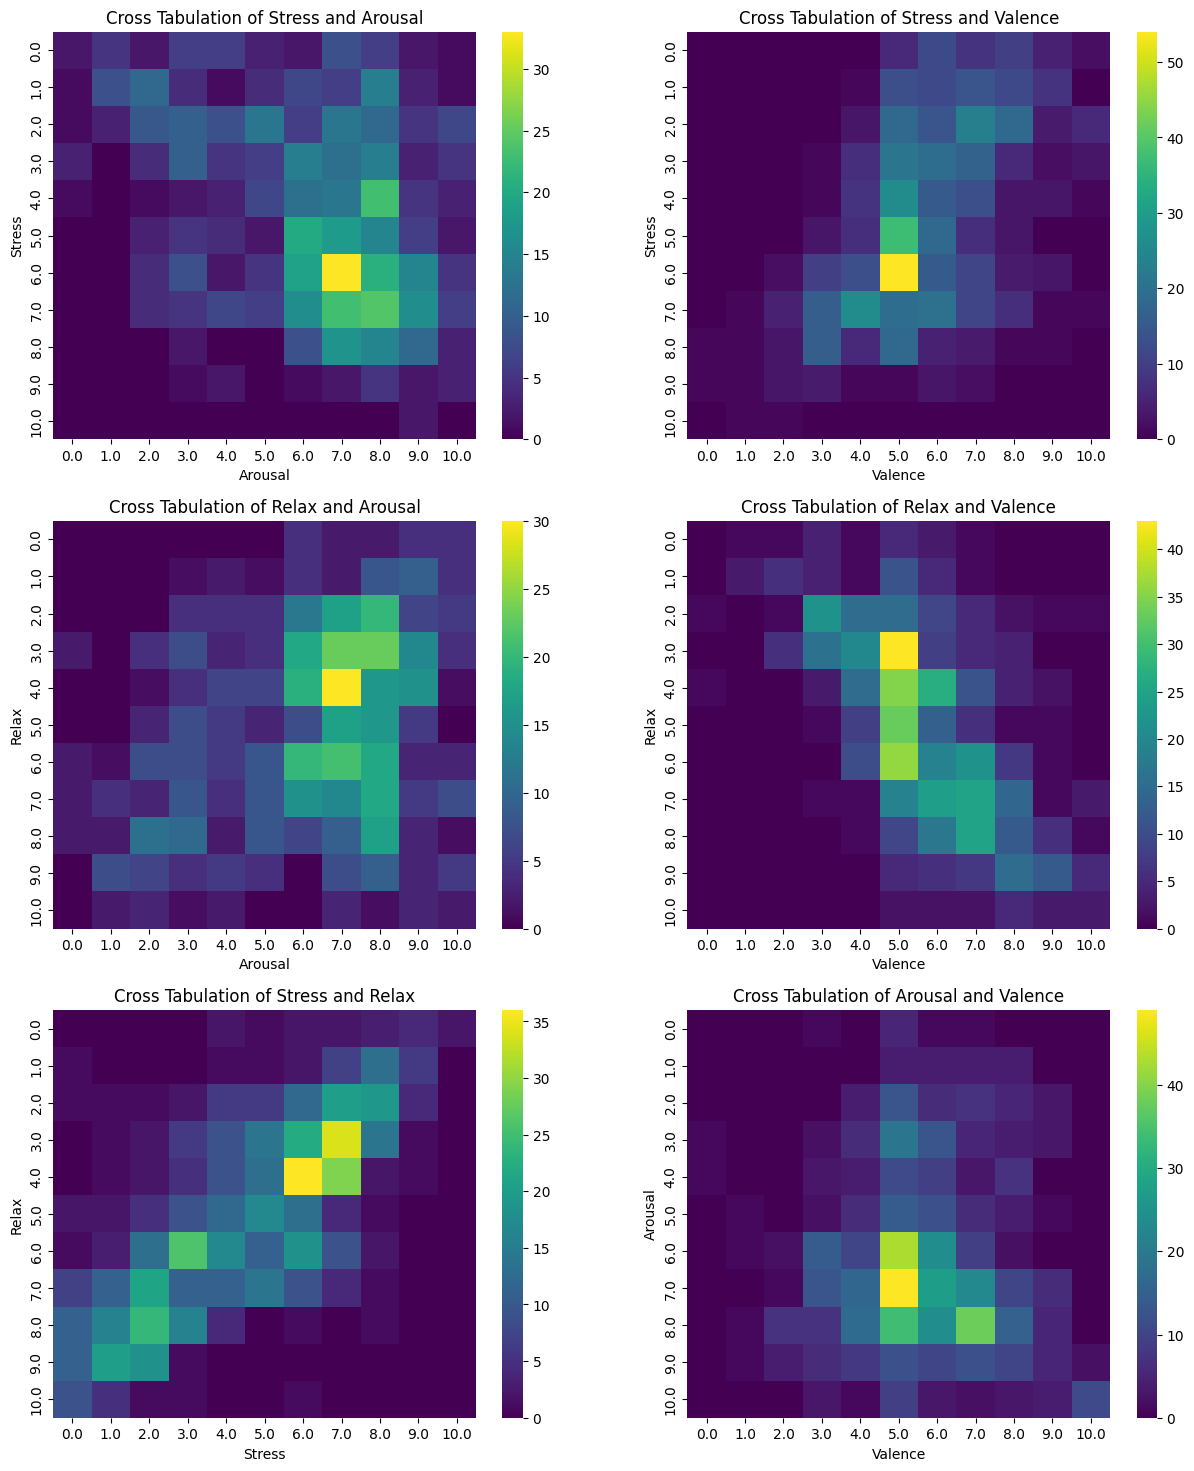

In [30]:
# Cross labels heatmapping
cross_stress_arousal = pd.crosstab(self_assessment_t['Stress'], self_assessment_t['Arousal'])
cross_stress_valence = pd.crosstab(self_assessment_t['Stress'], self_assessment_t['Valence'])
cross_relax_arousal = pd.crosstab(self_assessment_t['Relax'], self_assessment_t['Arousal'])
cross_relax_valence = pd.crosstab(self_assessment_t['Relax'], self_assessment_t['Valence'])
cross_relax_stress = pd.crosstab(self_assessment_t['Relax'], self_assessment_t['Stress'])
cross_arousal_valence = pd.crosstab(self_assessment_t['Arousal'], self_assessment_t['Valence'])

fig, axs = plt.subplots(3, 2, figsize=(15, 18))
sns.heatmap(cross_stress_arousal, fmt='d', cmap='viridis', ax=axs[0, 0])
axs[0, 0].set_title('Cross Tabulation of Stress and Arousal')
sns.heatmap(cross_stress_valence, fmt='d', cmap='viridis', ax=axs[0, 1])
axs[0, 1].set_title('Cross Tabulation of Stress and Valence')
sns.heatmap(cross_relax_arousal, fmt='d', cmap='viridis', ax=axs[1, 0])
axs[1, 0].set_title('Cross Tabulation of Relax and Arousal')
sns.heatmap(cross_relax_valence, fmt='d', cmap='viridis', ax=axs[1, 1])
axs[1, 1].set_title('Cross Tabulation of Relax and Valence')
sns.heatmap(cross_relax_stress, fmt='d', cmap='viridis', ax=axs[2, 0])
axs[2, 0].set_title('Cross Tabulation of Stress and Relax')
sns.heatmap(cross_arousal_valence, fmt='d', cmap='viridis', ax=axs[2, 1])
axs[2, 1].set_title('Cross Tabulation of Arousal and Valence')
plt.show()

In [33]:
fig = px.density_heatmap(self_assessment_t, x='Valence', y='Arousal', z='Stress', histfunc='avg',
                         color_continuous_scale='Viridis')
fig.update_layout(title='Density Heatmap of Stress with respect to Valence and Arousal',
                  xaxis_title='Valence',
                  yaxis_title='Arousal',
                  coloraxis_colorbar=dict(title='Average Stress'))
fig.show()

fig = px.density_heatmap(self_assessment_t, x='Valence', y='Arousal', z='Relax', histfunc='avg',
                         color_continuous_scale='Viridis')
fig.update_layout(title='Density Heatmap of Relax with respect to Valence and Arousal',
                  xaxis_title='Valence',
                  yaxis_title='Arousal',
                  coloraxis_colorbar=dict(title='Average Relax'))
fig.show()

In [52]:
fig = px.density_heatmap(self_assessment_t, 
                       self_assessment_t['Arousal'], 
                       self_assessment_t['Stress'], 
                       color_continuous_scale=px.colors.sequential.Viridis,
                       marginal_x="histogram", 
                       marginal_y="histogram",
                       width=600, height=500
                      )
fig.update_layout(title='Density Heatmap of Stress with respect to Arousal',
                  xaxis_title='Arousal',
                  yaxis_title='Stress',
                  coloraxis_colorbar=dict(title='Density of Stress'))
fig.show()

fig = px.density_heatmap(self_assessment_t, 
                       self_assessment_t['Valence'], 
                       self_assessment_t['Relax'], 
                       color_continuous_scale=px.colors.sequential.Viridis,
                       marginal_x="histogram", 
                       marginal_y="histogram",
                       width=600, height=500
                      )
fig.update_layout(title='Density Heatmap of Stress with respect to Valence',
                  xaxis_title='Valence',
                  yaxis_title='Stress',
                  coloraxis_colorbar=dict(title='Density of Stress'))
fig.show()

fig = px.density_heatmap(self_assessment_t, 
                       self_assessment_t['Valence'], 
                       self_assessment_t['Arousal'],
                       color_continuous_scale=px.colors.sequential.Viridis,
                       marginal_x="histogram", 
                       marginal_y="histogram",
                       width=600, height=500
                      )
fig.update_layout(title='Density Heatmap of Valence with respect to Arousal',
                  xaxis_title='Valence',
                  yaxis_title='Arousal',
                  coloraxis_colorbar=dict(title='Density of Valence'))
fig.show()

fig = px.density_heatmap(self_assessment_t, 
                       self_assessment_t['Relax'], 
                       self_assessment_t['Stress'],
                       color_continuous_scale=px.colors.sequential.Viridis,
                       marginal_x="histogram", 
                       marginal_y="histogram",
                       width=600, height=500
                      )
fig.update_layout(title='Density Heatmap of Relax with respect to Stress',
                  xaxis_title='Relax',
                  yaxis_title='Stress',
                  coloraxis_colorbar=dict(title='Density of Relax'))
fig.show()